In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/Saved_Models", exist_ok=True)
print("✅ Model save folder ready")
# import os
# os.listdir("/content/drive/MyDrive/Datasets/Osteoporosis Knee Dataset")
# os.listdir("/content/drive/MyDrive/Datasets/osteoporosis")
# os.listdir("/content/drive/MyDrive/Datasets/OS Collected Data")
# os.listdir("/content/drive/MyDrive/Datasets/Osteoporosis binary")


✅ Model save folder ready


In [ ]:
import numpy as np
import tensorflow as tf
import random
import os

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
import os

BASE_PATH = "/content/drive/MyDrive/Datasets/Unified_Osteoporosis"
NORMAL_PATH = os.path.join(BASE_PATH, "normal")
OSTEO_PATH  = os.path.join(BASE_PATH, "osteoporosis")

os.makedirs(NORMAL_PATH, exist_ok=True)
os.makedirs(OSTEO_PATH, exist_ok=True)

print("✅ Unified dataset folders created")
# healthy_dirs = [
#     "/content/drive/MyDrive/Datasets/Osteoporosis Knee Dataset/Normal",
#     "/content/drive/MyDrive/Datasets/osteoporosis/normal",
#     "/content/drive/MyDrive/Datasets/OS Collected Data/Normal",
#     "/content/drive/MyDrive/Datasets/Osteoporosis binary/normal"
# ]

# osteoporosis_dirs = [
#     "/content/drive/MyDrive/Datasets/Osteoporosis Knee Dataset/Osteoporosis",
#     "/content/drive/MyDrive/Datasets/osteoporosis/osteoporosis",
#     "/content/drive/MyDrive/Datasets/OS Collected Data/Osteoporosis",
#     "/content/drive/MyDrive/Datasets/Osteoporosis binary/osteoporosis"
# ]
# import os
# import shutil
# from tqdm import tqdm


# def copy_images(source_dirs, target_dir, prefix):
#     count = 0
#     for src in source_dirs:
#         if not os.path.exists(src):
#             print(f"❌ Folder not found: {src}")
#             continue

#         for file in tqdm(os.listdir(src)):
#             if file.lower().endswith((".png", ".jpg", ".jpeg")):
#                 src_path = os.path.join(src, file)
#                 new_name = f"{prefix}_{count}.jpg"
#                 dst_path = os.path.join(target_dir, new_name)
#                 shutil.copy(src_path, dst_path)
#                 count += 1

#     print(f"✅ Copied {count} images to {target_dir}")
# copy_images(healthy_dirs, NORMAL_PATH, "normal")
# copy_images(osteoporosis_dirs, OSTEO_PATH, "osteo")
import os

print("Normal images:", len(os.listdir(NORMAL_PATH)))
print("Osteoporosis images:", len(os.listdir(OSTEO_PATH)))


✅ Unified dataset folders created
Normal images: 1524
Osteoporosis images: 1539


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET_PATH = "/content/drive/MyDrive/Datasets/Unified_Osteoporosis"

img_size = (224, 224)
batch_size = 16

from sklearn.model_selection import train_test_split
import pandas as pd

# Create dataframe from directory
filepaths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    for file in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, file))
        labels.append(class_name)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

# 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2144
Validation: 459
Test: 460


Found 2144 validated image filenames belonging to 2 classes.
Found 459 validated image filenames belonging to 2 classes.
Found 460 validated image filenames belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 2,378,897 (9.07 MB)

...

Class weights: {0: np.float64(1.0046860356138707), 1: np.float64(0.9953574744661096)}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 141s 737ms/step - accuracy: 0.6163 - auc: 0.6558 - loss: 0.6454 - val_accuracy: 0.7625 - val_auc: 0.8092 - val_loss: 0.5056 - learning_rate: 3.0000e-05
Epoch 2/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 76s 564ms/step - accuracy: 0.7673 - auc: 0.8136 - loss: 0.5076 - val_accuracy: 0.7821 - val_auc: 0.8579 - val_loss: 0.4622 - learning_rate: 3.0000e-05
Epoch 3/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 75s 558ms/step - accuracy: 0.7614 - auc: 0.8369 - loss: 0.4898 - val_accuracy: 0.7996 - val_auc: 0.8705 - val_loss: 0.4464 - learning_rate: 3.0000e-05
Epoch 4/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 75s 561ms/step - accuracy: 0.7870 - auc: 0.8591 - loss: 0.4551 - val_accuracy: 0.8192 - val_auc: 0.8906 - val_loss: 0.4170 - learning_rate: 3.0000e-05
Epoch 5/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 75s 560ms/step - accuracy: 0.8075 - auc: 0.8725 - loss: 0.4347 - val_accuracy: 0.8148 - val_auc: 0.8989 - val_loss: 0.4024 - learning_rate: 3.0000e-05
Epoch 6/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 74s 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step
              precision    recall  f1-score   support

      normal       0.94      0.86      0.90       229
osteoporosis       0.88      0.95      0.91       231

    accuracy                           0.91       460
   macro avg       0.91      0.91      0.91       460
weighted avg       0.91      0.91      0.91       460



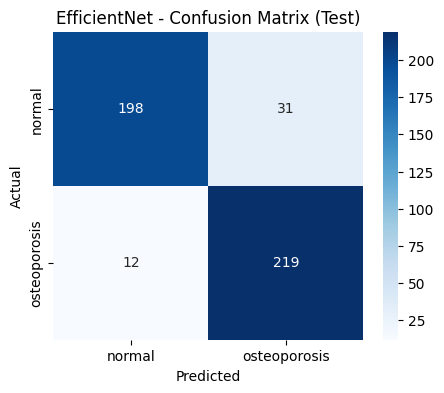

Found 459 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 655ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 441ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 472ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 477ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 470ms/step
              precision    recall  f1-score   support

      normal       0.95      0.93      0.94       228
osteoporosis       0.94      0.95      0.94       231

    accuracy                           0.94       459
   macro avg       0.94      0.94      0.94       459
weighted avg       0.94      0.94      0.94       459



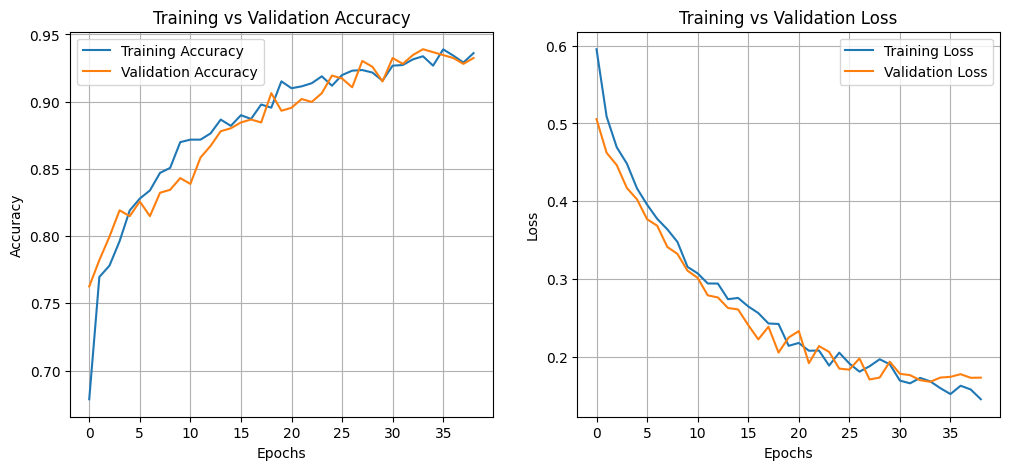

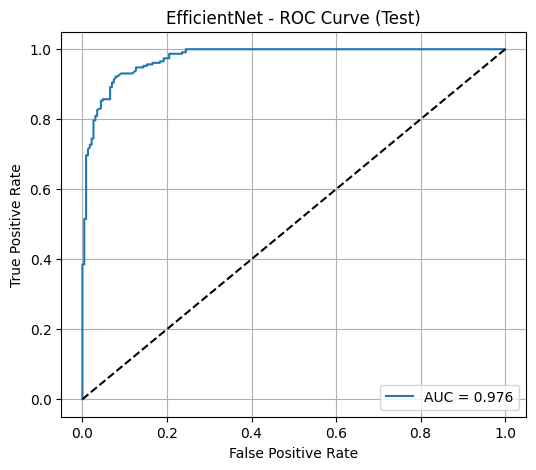

AUC Score: 0.9756706175920149
✅ EfficientNet model saved


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]

)

model.summary()

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

history = model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)
model.save("/content/drive/MyDrive/Saved_Models/efficientnet_model.keras")
print("✅ EfficientNet model saved")
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
eff_preds = model.predict(test_gen)
test_classes = (eff_preds > 0.5).astype(int).ravel()
true_classes = test_gen.classes

print(classification_report(
    true_classes,
    test_classes,
    target_names=test_gen.class_indices.keys()
))

cm = confusion_matrix(true_classes, test_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet - Confusion Matrix (Test)")
plt.show()
tta_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

tta_val_gen = tta_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

def tta_predict(model, generator, n_aug=5):
    preds = []
    for i in range(n_aug):
        generator.reset()
        preds.append(model.predict(generator))
    return np.mean(preds, axis=0)

tta_val_gen.reset()
val_true = tta_val_gen.classes


tta_preds = tta_predict(model, tta_val_gen, n_aug=5)
tta_classes = (tta_preds > 0.5).astype(int).ravel()

print(classification_report(
    val_true,
    tta_classes,
    target_names=tta_val_gen.class_indices.keys()
))
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_true_eff = test_gen.classes
y_scores = eff_preds.ravel()

fpr, tpr, _ = roc_curve(y_true_eff, y_scores)
roc_auc_efficientnet = auc(fpr, tpr)


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_efficientnet:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('EfficientNet - ROC Curve (Test)')
plt.legend()
plt.grid(True)
plt.show()

print("AUC Score:", roc_auc_efficientnet)

model.save("/content/drive/MyDrive/Saved_Models/efficientnet_model_with_tta.keras")
print("✅ EfficientNet model saved")







Found 2144 validated image filenames belonging to 2 classes.
Found 459 validated image filenames belonging to 2 classes.
Found 460 validated image filenames belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 115s 649ms/step - accuracy: 0.6694 - auc: 0.7295 - loss: 0.6156 - val_accuracy: 0.7952 - val_auc: 0.8874 - val_loss: 0.4494 - learning_rate: 3.0000e-05
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 79s 584ms/step - accuracy: 0.8021 - auc: 0.8879 - loss: 0.4180 - val_accuracy: 0.8235 - val_auc: 0.9326 - val_loss: 0.3685 - learning_rate: 3.0000e-05
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 77s 573ms/step - accuracy: 0.8816 - auc: 0.9439 - loss: 0.3078 - val_accuracy: 0.8649 - val_auc: 0.9501 - val_loss: 0.3098 - learning_rate: 3.0000e-05
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 78s 580ms/step - accuracy: 0.8759 - auc: 0.9515 - loss: 0.2798 - val_accuracy: 0.9063 - val_auc: 0.9736 - val_loss: 0.2201 - learning_rate: 3.0000e-05
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 77s 578ms/step - accuracy: 0.9115 - auc: 0.9745 - loss: 0.2100 - val_accuracy: 0.9020 - val_auc: 0.9643 - val_loss: 0.2458 - learning_rate: 3.0000e-05
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 78s 

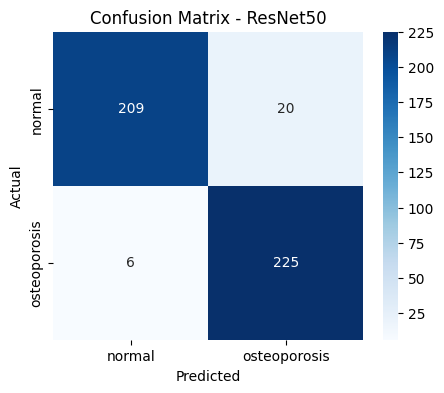

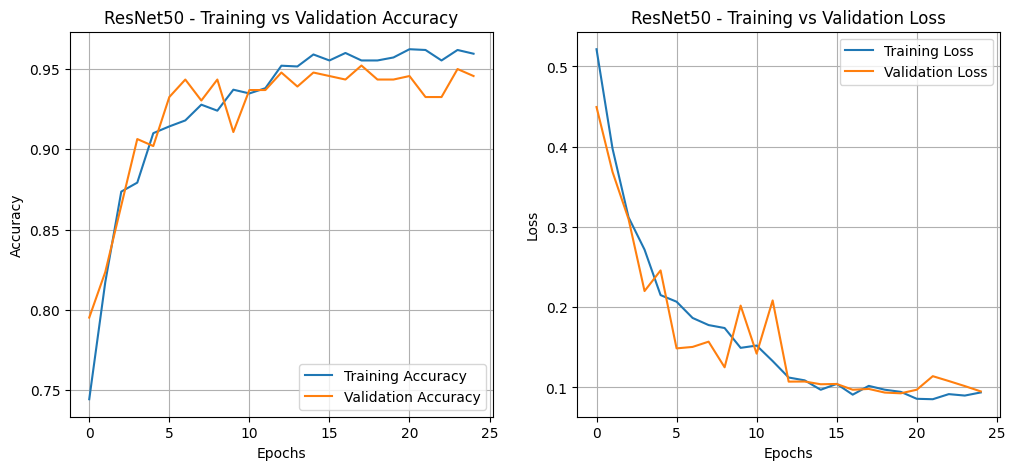

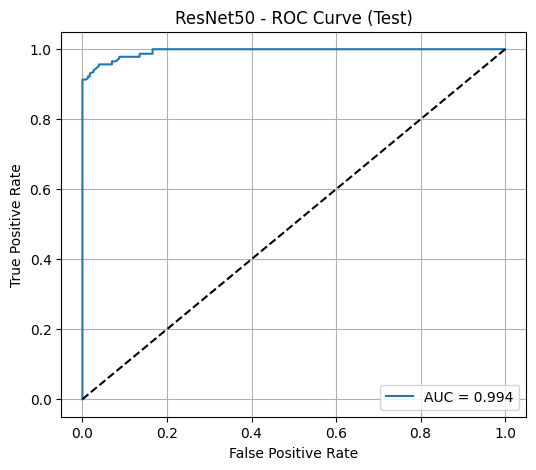

AUC Score: 0.9939129284107449


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen_resnet = train_datagen_resnet.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_gen_resnet = val_test_datagen_resnet.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

test_gen_resnet = val_test_datagen_resnet.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
import tensorflow as tf

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

model_resnet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]

)

history_resnet = model_resnet.fit(
    train_gen_resnet,
    epochs=30,
    validation_data=val_gen_resnet,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

model_resnet.save("/content/drive/MyDrive/Saved_Models/resnet_model.keras")
print("✅ ResNet50 model saved")

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_gen_resnet.reset()
pred_probs = model_resnet.predict(test_gen_resnet)
pred_classes = (pred_probs > 0.5).astype(int).ravel()
true_classes = test_gen_resnet.classes


# Classification Report
print(classification_report(
    true_classes,
    pred_classes,
    target_names=val_gen_resnet.class_indices.keys()
))

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen_resnet.class_indices.keys(),
            yticklabels=test_gen_resnet.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")
plt.show()

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet50 - Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet50 - Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_curve, auc

y_true_res = test_gen_resnet.classes
y_scores = pred_probs.ravel()   # ✅ Correct variable

fpr, tpr, _ = roc_curve(y_true_res, y_scores)
roc_auc_resnet = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_resnet:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ResNet50 - ROC Curve (Test)')
plt.legend()
plt.grid(True)
plt.show()

print("AUC Score:", roc_auc_resnet)



Found 2144 validated image filenames belonging to 2 classes.
Found 459 validated image filenames belonging to 2 classes.
Found 460 validated image filenames belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 121s 689ms/step - accuracy: 0.6561 - auc: 0.6967 - loss: 0.6447 - val_accuracy: 0.6819 - val_auc: 0.7856 - val_loss: 0.5767 - learning_rate: 3.0000e-05
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 78s 581ms/step - accuracy: 0.7714 - auc: 0.8436 - loss: 0.4829 - val_accuracy: 0.6863 - val_auc: 0.8327 - val_loss: 0.5416 - learning_rate: 3.0000e-05
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 75s 558ms/step - accuracy: 0.8012 - auc: 0.8725 - loss: 0.4451 - val_accuracy: 0.7298 - val_auc: 0.8727 - val_loss: 0.5007 - learning_rate: 3.0000e-05
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 75s 556ms/step - accuracy: 0.8381 - auc: 0.9080 - loss: 0.3843 - val_accuracy: 0.6885 - val_auc: 0.8838 - val_loss: 0.5364 - learning_rate: 3.0000e-05
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 75s 561ms/step - accuracy: 0.8214 - auc: 0.9073 - loss: 0.3848 - val_accuracy: 0.7429 - val_auc: 0.8960 - val_loss: 0.4673 - learning_rate: 3.0000e-05
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 74s 

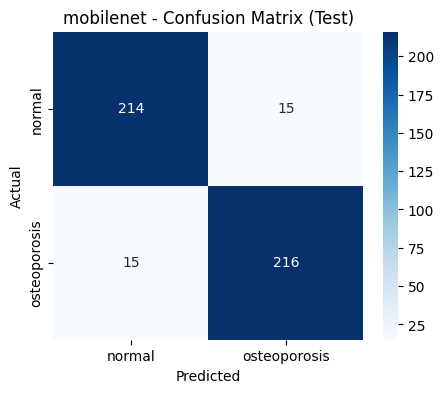

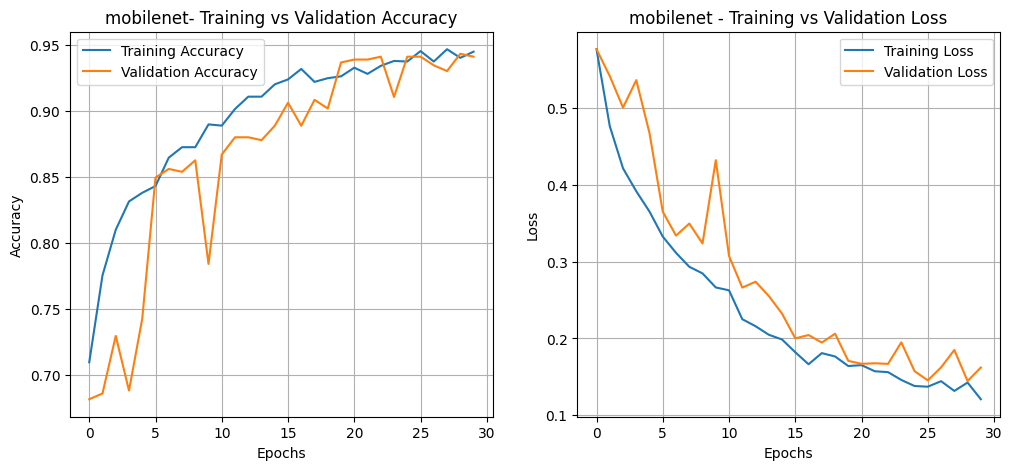

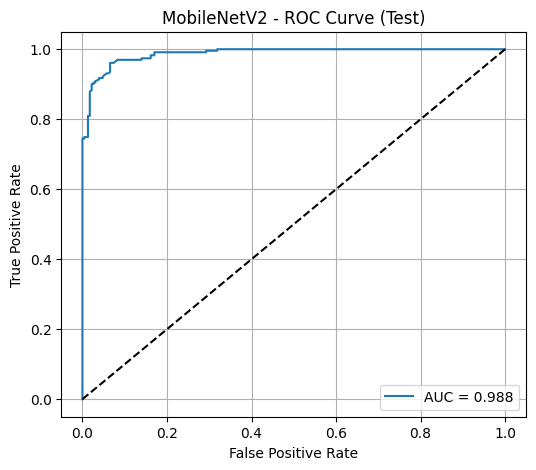

MobileNet AUC: 0.9875044896878958


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen_mobilenet = train_datagen_mobilenet.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_gen_mobilenet = val_test_datagen_mobilenet.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

test_gen_mobilenet = val_test_datagen_mobilenet.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

model_mobilenet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]

)

history_mobilenet = model_mobilenet.fit(
    train_gen_mobilenet,
    epochs=30,
    validation_data=val_gen_mobilenet,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)
model_mobilenet.save("/content/drive/MyDrive/Saved_Models/mobilenet_model.keras")
print("✅ MobileNet model saved")
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_gen_mobilenet.reset()
mobilenet_preds = model_mobilenet.predict(test_gen_mobilenet)
mobilenet_classes = (mobilenet_preds > 0.5).astype(int).ravel()
true_classes = test_gen_mobilenet.classes

print(classification_report(
    true_classes,
    mobilenet_classes,
    target_names=test_gen_mobilenet.class_indices.keys()
))

cm = confusion_matrix(true_classes, mobilenet_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen_mobilenet.class_indices.keys(),
            yticklabels=test_gen_mobilenet.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("mobilenet - Confusion Matrix (Test)")
plt.show()
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('mobilenet- Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['loss'], label='Training Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('mobilenet - Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()
from sklearn.metrics import roc_curve, auc

y_true_mob = test_gen_mobilenet.classes
y_scores = mobilenet_preds.ravel()

fpr, tpr, _ = roc_curve(y_true_mob, y_scores)
roc_auc_mobilenet = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_mobilenet:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MobileNetV2 - ROC Curve (Test)')
plt.legend()
plt.grid(True)
plt.show()

print("MobileNet AUC:", roc_auc_mobilenet)




Found 2144 validated image filenames belonging to 2 classes.
Found 459 validated image filenames belonging to 2 classes.
Found 460 validated image filenames belonging to 2 classes.
Class weights: {0: np.float64(1.0046860356138707), 1: np.float64(0.9953574744661096)}
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 141s 735ms/step - accuracy: 0.5710 - auc: 0.6087 - loss: 0.7491 - val_accuracy: 0.7538 - val_auc: 0.8195 - val_loss: 0.5148 - learning_rate: 3.0000e-05
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 71s 532ms/step - accuracy: 0.7062 - auc: 0.7759 - loss: 0.5883 - val_accuracy: 0.7712 - val_auc: 0.8420 - val_loss: 0.4803 - learning_rate: 3.0000e-05
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 72s 541ms/step - accuracy: 0.7311 - auc: 0.8028 - loss: 0.5501 - val_accuracy: 0.7843 - val_auc: 0.8573 - val_loss: 0.4627 - learning_rate: 3.0000e-05
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 73s 543ms/step - accuracy: 0.7729 - auc: 0.8260 - loss: 0.5117 - val_accuracy: 0.8061 - val_auc: 0.8740 - val_loss: 0.4520 - learning_rate: 3.0000e-05
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 71s 530ms/step - accuracy: 0.8091 - auc: 0.8787 - loss: 0.4360 - val_accuracy: 0.8105 - val_auc: 0.8874 - val_loss: 0.4217 - learning_rate: 3.0000e-05
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 70s 

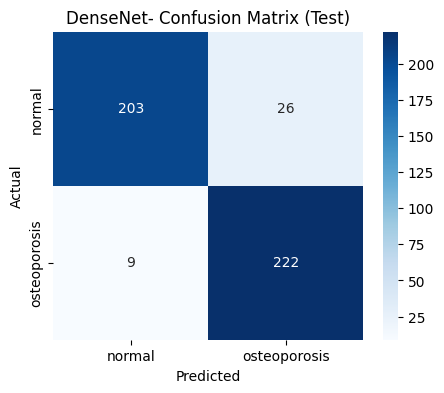

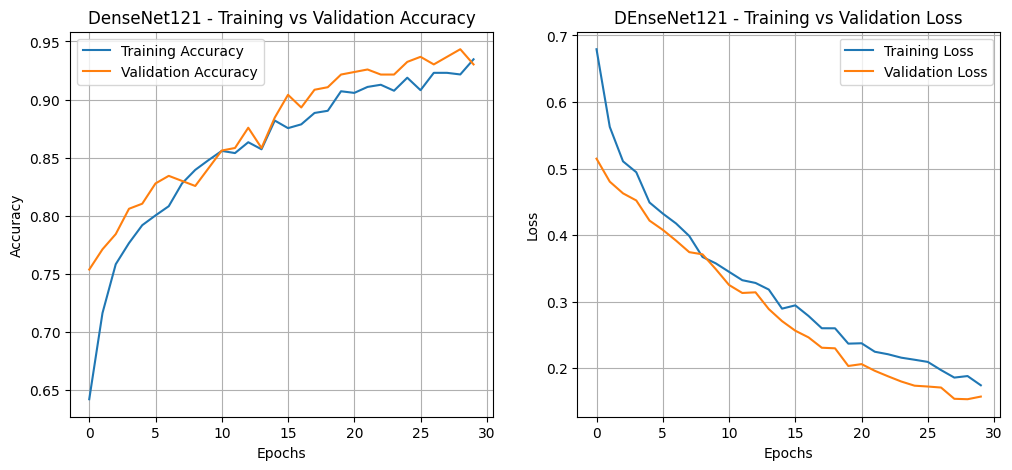

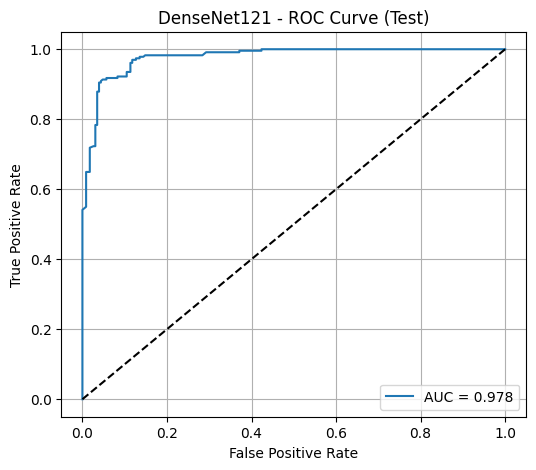

DenseNet AUC: 0.9775610124955103


In [ ]:
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)


train_datagen_densenet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen_densenet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen_densenet = train_datagen_densenet.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_gen_densenet = val_test_datagen_densenet.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

test_gen_densenet = val_test_datagen_densenet.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen_densenet.classes),
    y=train_gen_densenet.classes
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

model_densenet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_densenet.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]

)

history_densenet = model_densenet.fit(
    train_gen_densenet,
    epochs=30,
    validation_data=val_gen_densenet,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)
model_densenet.save("/content/drive/MyDrive/Saved_Models/densenet_model.keras")
print("✅ DenseNet model saved")

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_gen_densenet.reset()
densenet_preds = model_densenet.predict(test_gen_densenet)
densenet_classes = (densenet_preds > 0.5).astype(int).ravel()
true_classes = test_gen_densenet.classes

print(classification_report(
    true_classes,
    densenet_classes,
    target_names=test_gen_densenet.class_indices.keys()
))

cm = confusion_matrix(true_classes, densenet_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen_densenet.class_indices.keys(),
            yticklabels=test_gen_densenet.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet- Confusion Matrix (Test)")
plt.show()
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history_densenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_densenet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('DenseNet121 - Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_densenet.history['loss'], label='Training Loss')
plt.plot(history_densenet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('DEnseNet121 - Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

y_true_den = test_gen_densenet.classes
y_scores = densenet_preds.ravel()

fpr, tpr, _ = roc_curve(y_true_den, y_scores)
roc_auc_densenet = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_densenet:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DenseNet121 - ROC Curve (Test)')
plt.legend()
plt.grid(True)
plt.show()

print("DenseNet AUC:", roc_auc_densenet)




📊 Final Model Comparison:
            Model       AUC
1        ResNet50  0.993913
2     MobileNetV2  0.987504
3     DenseNet121  0.977561
0  EfficientNetB0  0.975671


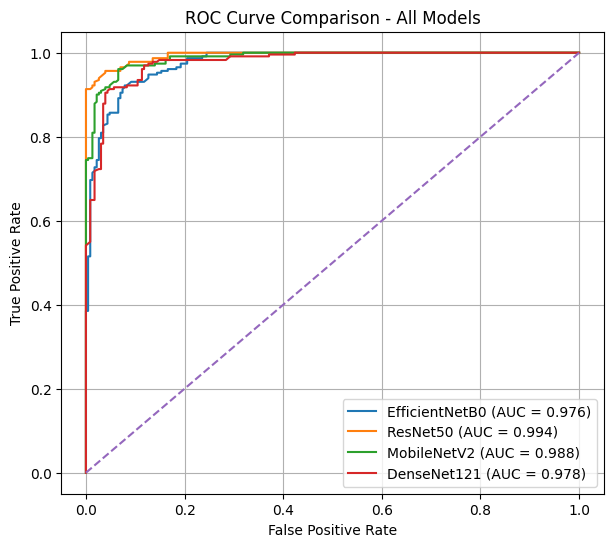

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["EfficientNetB0", "ResNet50", "MobileNetV2", "DenseNet121"],
    "AUC": [
        roc_auc_efficientnet,
        roc_auc_resnet,
        roc_auc_mobilenet,
        roc_auc_densenet
    ]
})

print("\n📊 Final Model Comparison:")
print(results.sort_values(by="AUC", ascending=False))

best_index = results["AUC"].idxmax()
best_model_name = results.loc[best_index, "Model"]
print("Best Binary Model:", best_model_name)
import json

with open("/content/drive/MyDrive/Saved_Models/best_binary_model_info.json", "w") as f:
    json.dump({"model_name": best_model_name}, f)

if best_model_name == "EfficientNetB0":
    model.save("/content/drive/MyDrive/Saved_Models/best_binary_model.keras")

elif best_model_name == "ResNet50":
    model_resnet.save("/content/drive/MyDrive/Saved_Models/best_binary_model.keras")

elif best_model_name == "MobileNetV2":
    model_mobilenet.save("/content/drive/MyDrive/Saved_Models/best_binary_model.keras")

elif best_model_name == "DenseNet121":
    model_densenet.save("/content/drive/MyDrive/Saved_Models/best_binary_model.keras")
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# EfficientNet
fpr_eff, tpr_eff, _ = roc_curve(y_true_eff, eff_preds.ravel())
roc_auc_efficientnet= auc(fpr_eff, tpr_eff)

# ResNet
fpr_res, tpr_res, _ = roc_curve(y_true_res, pred_probs.ravel())
roc_auc_resnet = auc(fpr_res, tpr_res)

# MobileNet
fpr_mob, tpr_mob, _ = roc_curve(y_true_mob, mobilenet_preds.ravel())
roc_auc_mobilenet= auc(fpr_mob, tpr_mob)

# DenseNet
fpr_den, tpr_den, _ = roc_curve(y_true_den, densenet_preds.ravel())
roc_auc_densenet = auc(fpr_den, tpr_den)

# Plot everything together
plt.figure(figsize=(7,6))

plt.plot(fpr_eff, tpr_eff, label=f'EfficientNetB0 (AUC = {roc_auc_efficientnet:.3f})')
plt.plot(fpr_res, tpr_res, label=f'ResNet50 (AUC = {roc_auc_resnet:.3f})')
plt.plot(fpr_mob, tpr_mob, label=f'MobileNetV2 (AUC = {roc_auc_mobilenet:.3f})')
plt.plot(fpr_den, tpr_den, label=f'DenseNet121 (AUC = {roc_auc_densenet:.3f})')

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Models")
plt.legend()
plt.grid(True)

plt.show()



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# ---------- EfficientNet ----------
eff_accuracy  = accuracy_score(y_true_eff, test_classes)
eff_precision = precision_score(y_true_eff, test_classes, zero_division=0)
eff_recall    = recall_score(y_true_eff, test_classes, zero_division=0)
eff_f1        = f1_score(y_true_eff, test_classes, zero_division=0)
eff_auc       = roc_auc_score(y_true_eff, eff_preds.ravel())

# ---------- ResNet ----------
res_accuracy  = accuracy_score(y_true_res, pred_classes)
res_precision = precision_score(y_true_res, pred_classes, zero_division=0)
res_recall    = recall_score(y_true_res, pred_classes, zero_division=0)
res_f1        = f1_score(y_true_res, pred_classes, zero_division=0)
res_auc       = roc_auc_score(y_true_res, pred_probs.ravel())

# ---------- MobileNet ----------
mob_accuracy  = accuracy_score(y_true_mob, mobilenet_classes)
mob_precision = precision_score(y_true_mob, mobilenet_classes, zero_division=0)
mob_recall    = recall_score(y_true_mob, mobilenet_classes, zero_division=0)
mob_f1        = f1_score(y_true_mob, mobilenet_classes, zero_division=0)
mob_auc       = roc_auc_score(y_true_mob, mobilenet_preds.ravel())

# ---------- DenseNet ----------
den_accuracy  = accuracy_score(y_true_den, densenet_classes)
den_precision = precision_score(y_true_den, densenet_classes, zero_division=0)
den_recall    = recall_score(y_true_den, densenet_classes, zero_division=0)
den_f1        = f1_score(y_true_den, densenet_classes, zero_division=0)
den_auc       = roc_auc_score(y_true_den, densenet_preds.ravel())

# ---------- Create Table ----------
results = pd.DataFrame({
    "Model": ["EfficientNetB0", "ResNet50", "MobileNetV2", "DenseNet121"],
    "Accuracy":  [eff_accuracy, res_accuracy, mob_accuracy, den_accuracy],
    "Precision": [eff_precision, res_precision, mob_precision, den_precision],
    "Recall":    [eff_recall, res_recall, mob_recall, den_recall],
    "F1-Score":  [eff_f1, res_f1, mob_f1, den_f1],
    "AUC":       [eff_auc, res_auc, mob_auc, den_auc]
})

print("\n📊 Final Model Evaluation Metrics (Test Set)")
print(results.sort_values(by="AUC", ascending=False).reset_index(drop=True))


📊 Final Model Evaluation Metrics (Test Set)
            Model  Accuracy  Precision    Recall  F1-Score       AUC
0        ResNet50  0.943478   0.918367  0.974026  0.945378  0.993913
1     MobileNetV2  0.934783   0.935065  0.935065  0.935065  0.987504
2     DenseNet121  0.923913   0.895161  0.961039  0.926931  0.977561
3  EfficientNetB0  0.906522   0.876000  0.948052  0.910603  0.975671


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load best model
best_model = load_model("/content/drive/MyDrive/Saved_Models/best_binary_model.keras")

IMG_SIZE = (224, 224)

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    import json

    with open("/content/drive/MyDrive/Saved_Models/best_binary_model_info.json", "r") as f:
        model_info = json.load(f)

    model_name = model_info["model_name"]

    if model_name == "EfficientNetB0":
        img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    elif model_name == "ResNet50":
        img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
    elif model_name == "MobileNetV2":
        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    elif model_name == "DenseNet121":
        img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    prediction = best_model.predict(img_array)[0][0]

    if prediction > 0.5:
        label = "Osteoporosis"
        risk = prediction * 100
    else:
        label = "Normal"
        risk = (1 - prediction) * 100

    print(f"Prediction: {label}")
    print(f"Risk Score: {risk:.2f}%")

    return label, risk